In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Model & Evaluation Modules
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Set visualization style
sns.set_theme(style="whitegrid")

# Dynamic Path Resolution for Processed CSV
POSSIBLE_PATHS = [
    os.path.abspath(os.path.join("..", "data", "processed", "processed_data.csv")),
    os.path.abspath(os.path.join("data", "processed", "processed_data.csv")),
    os.path.abspath(os.path.join(os.getcwd(), "data", "processed", "processed_data.csv")),
    os.path.abspath(os.path.join(os.getcwd(), "..", "data", "processed", "processed_data.csv"))
]

PROCESSED_PATH = None
for path in POSSIBLE_PATHS:
    if os.path.exists(path):
        PROCESSED_PATH = path
        break

if not PROCESSED_PATH:
    raise FileNotFoundError("processed_data.csv was not found. Please run Notebook 01 first.")

# Load Cleaned Dataset
df = pd.read_csv(PROCESSED_PATH)
print(f"Successfully loaded dataset from: {PROCESSED_PATH}")
print(f"Dataset shape: {df.shape}")
df.head()

Successfully loaded dataset from: d:\SIG Project\smartphone-absa-project\data\processed\processed_data.csv
Dataset shape: (57828, 11)


,asin,name,rating,date,verified,title,body,helpfulvotes,brand,clean_review,review_length
0,B0000SX2UC,Janet,3,"October 11, 2005",False,"Def not best, but not worst",I had the Samsung A600 for awhile which is abs...,1.0,DEF,I had the Samsung A600 for awhile which is abs...,327
1,B0000SX2UC,Luke Wyatt,1,"January 7, 2004",False,Text Messaging Doesn't Work,Due to a software issue between Nokia and Spri...,17.0,TEXT,Due to a software issue between Nokia and Spri...,129
2,B0000SX2UC,Brooke,5,"December 30, 2003",False,Love This Phone,"This is a great, reliable phone. I also purcha...",5.0,LOVE,"This is a great, reliable phone. I also purcha...",131
3,B0000SX2UC,amy m. teague,3,"March 18, 2004",False,"Love the Phone, BUT...!","I love the phone and all, because I really did...",1.0,LOVE,"I love the phone and all, because I really did...",107
4,B0000SX2UC,tristazbimmer,4,"August 28, 2005",False,"Great phone service and options, lousy case!",The phone has been great for every purpose it ...,1.0,GREAT,The phone has been great for every purpose it ...,128


--- Sentiment Class Distribution (%) ---
sentiment_class
Positive    65.753614
Negative    26.679117
Neutral      7.567268
Name: proportion, dtype: float64


C:\Users\iworld\AppData\Local\Temp\ipykernel_18964\2225426866.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment_class", order=["Negative", "Neutral", "Positive"], palette="viridis")


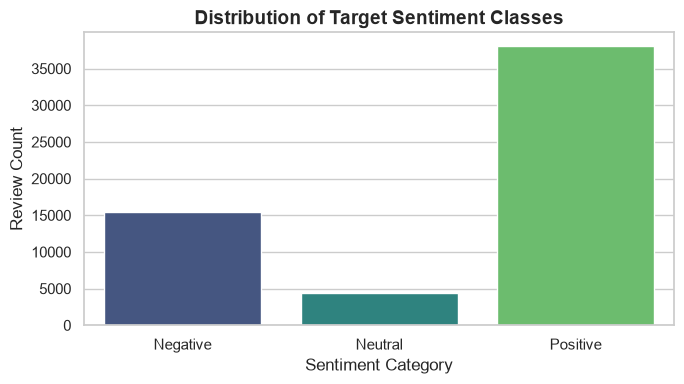

In [2]:
# Identify rating column dynamically
rating_col = next((col for col in ["rating", "ratings", "score"] if col in df.columns), None)

# Bin numeric ratings into 3 sentiment classes
def categorize_rating(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["sentiment_class"] = df[rating_col].apply(categorize_rating)

print("--- Sentiment Class Distribution (%) ---")
print(df["sentiment_class"].value_counts(normalize=True) * 100)

# Visualize Class Distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="sentiment_class", order=["Negative", "Neutral", "Positive"], palette="viridis")
plt.title("Distribution of Target Sentiment Classes", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment Category", fontsize=12)
plt.ylabel("Review Count", fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
# Features (X) and Target (y)
X = df["clean_review"].fillna("").astype(str)
y = df["sentiment_class"]

# Stratified Train-Test Split (80% Train / 20% Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Initialize TF-IDF Vectorizer (top 5,000 unigrams and bigrams)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")

# Fit on training data; transform both train and test sets
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

print(f"Train Matrix Shape (TF-IDF): {X_train_tfidf.shape}")
print(f"Test Matrix Shape (TF-IDF):  {X_test_tfidf.shape}")

Train Matrix Shape (TF-IDF): (46262, 5000)
Test Matrix Shape (TF-IDF):  (11566, 5000)


In [4]:
# Define model dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
}

comparison_results = []

for name, model in models.items():
    # 1. Model Training
    model.fit(X_train_tfidf, y_train)
    
    # 2. Prediction on Test Set
    y_pred = model.predict(X_test_tfidf)
    
    # 3. Calculate Performance Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    comparison_results.append({
        "Model Algorithm": name,
        "Accuracy": round(acc, 4),
        "Weighted F1-Score": round(f1, 4)
    })
    
    print(f"\n==================== {name} ====================")
    print(classification_report(y_test, y_pred))

# Display Comparison Summary DataFrame
df_summary = pd.DataFrame(comparison_results).sort_values(by="Weighted F1-Score", ascending=False)
print("\n--- Model Benchmark Summary ---")
print(df_summary.to_string(index=False))


==================== Logistic Regression ====================
              precision    recall  f1-score   support

    Negative       0.77      0.80      0.78      3086
     Neutral       0.35      0.05      0.09       875
    Positive       0.87      0.94      0.91      7605

    accuracy                           0.84     11566
   macro avg       0.66      0.60      0.59     11566
weighted avg       0.80      0.84      0.81     11566


==================== Multinomial Naive Bayes ====================
              precision    recall  f1-score   support

    Negative       0.78      0.74      0.76      3086
     Neutral       0.26      0.01      0.01       875
    Positive       0.84      0.95      0.89      7605

    accuracy                           0.82     11566
   macro avg       0.63      0.57      0.55     11566
weighted avg       0.78      0.82      0.79     11566


==================== Random Forest ====================
              precision    recall  f1-score   suppo

d:\SIG Project\smartphone-absa-project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\SIG Project\smartphone-absa-project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\SIG Project\smartphone-absa-project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

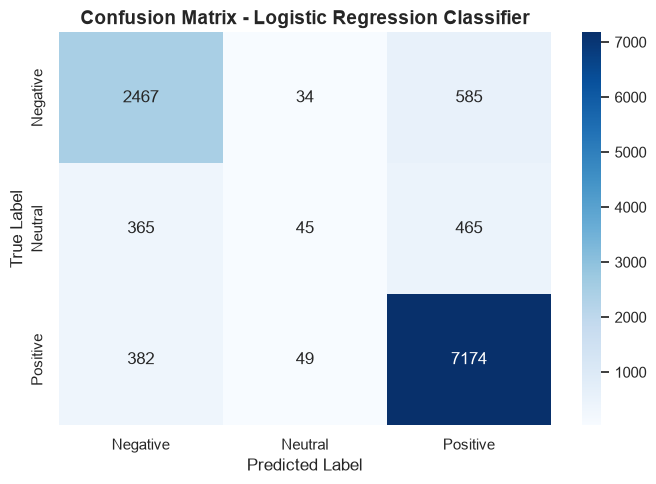

--- Live Inference on Sample Smartphone Aspects ---
Phrase: 'the camera picture quality is super crisp and vibrant'
Predicted Sentiment: Positive
Probabilities: {'Negative': np.float64(0.0582), 'Neutral': np.float64(0.0376), 'Positive': np.float64(0.9042)}

Phrase: 'battery life drains rapidly and gets extremely hot'
Predicted Sentiment: Negative
Probabilities: {'Negative': np.float64(0.659), 'Neutral': np.float64(0.2256), 'Positive': np.float64(0.1154)}

Phrase: 'display is okay for the price, nothing special'
Predicted Sentiment: Neutral
Probabilities: {'Negative': np.float64(0.1125), 'Neutral': np.float64(0.5022), 'Positive': np.float64(0.3852)}



In [5]:
# Select and train the primary model (Logistic Regression)
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train_tfidf, y_train)
y_pred_best = best_model.predict(X_test_tfidf)

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best, labels=["Negative", "Neutral", "Positive"])

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)
plt.title("Confusion Matrix - Logistic Regression Classifier", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()

# Inference Function for Custom Aspect Phrases
def predict_aspect_sentiment(phrase):
    vec = tfidf.transform([phrase])
    pred = best_model.predict(vec)[0]
    probabilities = best_model.predict_proba(vec)[0]
    prob_map = {cls: round(prob, 4) for cls, prob in zip(best_model.classes_, probabilities)}
    return pred, prob_map

# Test Sample Aspect Snippets
test_phrases = [
    "the camera picture quality is super crisp and vibrant",
    "battery life drains rapidly and gets extremely hot",
    "display is okay for the price, nothing special"
]

print("--- Live Inference on Sample Smartphone Aspects ---")
for phrase in test_phrases:
    sentiment, probs = predict_aspect_sentiment(phrase)
    print(f"Phrase: '{phrase}'")
    print(f"Predicted Sentiment: {sentiment}")
    print(f"Probabilities: {probs}\n")